# Phase 6: Ablation Study & Cold-Start Analysis

This phase addresses two critical research questions left open by the Phase 4-5 benchmark:

1. **Ablation:** Is the performance gain of FA-LightGCN due to the GNN architecture, or does the feature projection initialization specifically contribute?
2. **Cold-Start:** Does the feature augmentation provide robustness when users have few interactions â€” the scenario where pure collaborative filtering typically collapses?

## Objectives
1. Train a **Standard LightGCN** (random init, no feature projection) under identical conditions as FA-LightGCN.
2. Compare both variants on the full test set to isolate the contribution of feature initialization.
3. Stratify all models by **user activity level** and measure degradation on cold users (â‰¤10 training interactions).
4. Produce a degradation curve validating the practical advantage of the hybrid design.

## Setup

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import LGConv
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\RoG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


### Data Loading

In [2]:
# Raw features & edges
user_features_raw = np.load('processed_data/user_features.npy')
item_features_raw = np.load('processed_data/item_features.npy')
train_df = pd.read_csv('processed_data/train_edges.csv')
test_df  = pd.read_csv('processed_data/test_edges.csv')
test_neg_df = pd.read_csv('processed_data/test_neg_edges.csv')

with open('processed_data/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

num_users = metadata['num_users']
num_items = metadata['num_items']
print(f"Users: {num_users} | Items: {num_items}")
print(f"Train edges: {len(train_df)} | Test edges: {len(test_df)}")

# Normalize features (same pipeline as Phase 4)
user_scaler = StandardScaler()
item_scaler = MinMaxScaler()
user_features = torch.tensor(user_scaler.fit_transform(user_features_raw), dtype=torch.float)
item_features = torch.tensor(item_scaler.fit_transform(item_features_raw), dtype=torch.float)

# Pre-computed FA-LightGCN embeddings from Phase 4
fa_user_emb = torch.tensor(np.load('results/lightgcn_user_embeddings.npy'), dtype=torch.float)
fa_item_emb = torch.tensor(np.load('results/lightgcn_movie_embeddings.npy'), dtype=torch.float)
print(f"FA-LightGCN embeddings loaded: users {fa_user_emb.shape}, items {fa_item_emb.shape}")

Users: 943 | Items: 1682
Train edges: 44300 | Test edges: 11075
FA-LightGCN embeddings loaded: users torch.Size([943, 64]), items torch.Size([1682, 64])


### Graph Construction

In [3]:
data = HeteroData()
data['user'].x  = user_features
data['movie'].x = item_features

edge_index = torch.tensor(
    [train_df['user_idx'].values, train_df['item_idx'].values], dtype=torch.long
)
data['user', 'rates', 'movie'].edge_index = edge_index
data['movie', 'rated_by', 'user'].edge_index = torch.stack([edge_index[1], edge_index[0]])
data = data.to(device)
print(data)

HeteroData(
  user={ x=[943, 3] },
  movie={ x=[1682, 19] },
  (user, rates, movie)={ edge_index=[2, 44300] },
  (movie, rated_by, user)={ edge_index=[2, 44300] }
)


### Shared Utilities (BPR Loss, Metrics, Evaluation)

In [4]:
def bpr_loss(pos_scores, neg_scores):
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()


def get_metrics(rankings):
    """Compute ranking metrics from a list of positive-item ranks (0-indexed in a pool of 100)."""
    rankings = np.array(rankings)
    recall_10    = (rankings < 10).astype(float).mean()
    precision_10 = recall_10 / 10
    auc          = ((99 - rankings) / 99.0).mean()
    ndcg_10 = map_10 = 0.0
    for r in rankings:
        if r < 10:
            ndcg_10 += 1 / np.log2(r + 2)
            map_10  += 1 / (r + 1)
    ndcg_10 /= len(rankings)
    map_10  /= len(rankings)
    return recall_10, ndcg_10, auc, precision_10, map_10


def evaluate_from_embeddings(user_emb, item_emb, test_df, test_neg_df, user_subset=None):
    """
    Evaluate ranking metrics directly from pre-computed embedding matrices.
    user_subset: optional list/array of user_idx to restrict evaluation.
    """
    unique_users = test_df['user_idx'].unique()
    if user_subset is not None:
        unique_users = np.intersect1d(unique_users, user_subset)

    rankings = []
    for user_idx in unique_users:
        pos_item  = test_df[test_df['user_idx'] == user_idx]['item_idx'].values[0]
        neg_items = test_neg_df[test_neg_df['user_idx'] == user_idx]['item_idx'].values
        items = np.concatenate([[pos_item], neg_items])

        u_e = user_emb[user_idx].unsqueeze(0)  # (1, d)
        i_e = item_emb[items]                  # (100, d)
        scores = torch.matmul(u_e, i_e.t()).squeeze(0)

        _, indices = torch.sort(scores, descending=True)
        rank = (indices == 0).nonzero(as_tuple=True)[0].item()
        rankings.append(rank)

    return get_metrics(rankings)


def evaluate_model(model, data, test_df, test_neg_df, user_subset=None):
    """Evaluate a GNN model, optionally restricted to user_subset."""
    model.eval()
    with torch.no_grad():
        z = model(data.x_dict, data.edge_index_dict)
        u_emb = z['user'].cpu()
        i_emb = z['movie'].cpu()
    return evaluate_from_embeddings(u_emb, i_emb, test_df, test_neg_df, user_subset)


print("Utilities ready.")

Utilities ready.


---
## Part 1: Ablation Study â€” Standard LightGCN vs FA-LightGCN

We isolate the contribution of **feature projection** by training a LightGCN variant with a single change: random ID embeddings replace the content-projected initialization. All other hyperparameters (embedding dim, layers, learning rate, epochs) remain identical to Phase 4.

### 1.1 Model Definitions

In [5]:
EMBEDDING_DIM = 64
NUM_LAYERS    = 3


# â”€â”€ Feature-Augmented LightGCN (Phase 4 architecture) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class FALightGCN(nn.Module):
    """LightGCN with content-feature projection + learnable residual ID embedding."""

    def __init__(self, num_users, num_items, user_feat_dim, item_feat_dim,
                 embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_users    = num_users
        self.num_items    = num_items
        self.embedding_dim = embedding_dim
        self.num_layers   = num_layers

        # Content projection
        self.linear_user = nn.Linear(user_feat_dim, embedding_dim)
        self.linear_item = nn.Linear(item_feat_dim, embedding_dim)

        # Residual collaborative embedding
        self.user_emb_res = nn.Embedding(num_users, embedding_dim)
        self.item_emb_res = nn.Embedding(num_items, embedding_dim)
        nn.init.normal_(self.user_emb_res.weight, std=0.1)
        nn.init.normal_(self.item_emb_res.weight, std=0.1)

        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

    def _bipartite_edge_index(self, edge_index_dict):
        ei = edge_index_dict[('user', 'rates', 'movie')]
        u, v = ei[0], ei[1] + self.num_users
        return torch.stack([torch.cat([u, v]), torch.cat([v, u])])

    def forward(self, x_dict, edge_index_dict):
        u_emb = self.linear_user(x_dict['user'])  + self.user_emb_res.weight
        i_emb = self.linear_item(x_dict['movie']) + self.item_emb_res.weight
        x = torch.cat([u_emb, i_emb], dim=0)

        adj = self._bipartite_edge_index(edge_index_dict)
        layers = [x]
        for conv in self.convs:
            x = conv(x, adj)
            layers.append(x)
        out = torch.mean(torch.stack(layers), dim=0)
        return {'user': out[:self.num_users], 'movie': out[self.num_users:]}


# â”€â”€ Standard LightGCN (random init â€” ablation control) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class StandardLightGCN(nn.Module):
    """Vanilla LightGCN with purely random ID embeddings. No content features."""

    def __init__(self, num_users, num_items, embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_users    = num_users
        self.num_items    = num_items
        self.embedding_dim = embedding_dim
        self.num_layers   = num_layers

        # Collaborative embeddings only â€” no content projection
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

    def _bipartite_edge_index(self, edge_index_dict):
        ei = edge_index_dict[('user', 'rates', 'movie')]
        u, v = ei[0], ei[1] + self.num_users
        return torch.stack([torch.cat([u, v]), torch.cat([v, u])])

    def forward(self, x_dict, edge_index_dict):
        x = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        adj = self._bipartite_edge_index(edge_index_dict)
        layers = [x]
        for conv in self.convs:
            x = conv(x, adj)
            layers.append(x)
        out = torch.mean(torch.stack(layers), dim=0)
        return {'user': out[:self.num_users], 'movie': out[self.num_users:]}


print("Models defined.")
print(f"  FA-LightGCN  â€” content projection + residual ID embedding")
print(f"  StandardLightGCN â€” random ID embedding only (ablation control)")

Models defined.
  FA-LightGCN  â€” content projection + residual ID embedding
  StandardLightGCN â€” random ID embedding only (ablation control)


### 1.2 Trainer

In [6]:
class GNNTrainer:
    def __init__(self, model, optimizer, data, train_df, test_df, test_neg_df):
        self.model       = model
        self.optimizer   = optimizer
        self.data        = data
        self.train_df    = train_df
        self.test_df     = test_df
        self.test_neg_df = test_neg_df
        self.history     = {'loss': [], 'recall': [], 'ndcg': [], 'auc': [], 'precision': [], 'map': []}

    def train_epoch(self, batch_size=1024):
        self.model.train()
        total_loss = 0
        indices = torch.randperm(len(self.train_df))
        for i in range(0, len(indices), batch_size):
            self.optimizer.zero_grad()
            batch = indices[i:i + batch_size]
            users     = torch.tensor(self.train_df.iloc[batch.numpy()]['user_idx'].values).to(device)
            pos_items = torch.tensor(self.train_df.iloc[batch.numpy()]['item_idx'].values).to(device)
            neg_items = torch.randint(0, num_items, (len(users),)).to(device)

            z = self.model(self.data.x_dict, self.data.edge_index_dict)
            u_e   = z['user'][users]
            pos_e = z['movie'][pos_items]
            neg_e = z['movie'][neg_items]

            loss = bpr_loss((u_e * pos_e).sum(-1), (u_e * neg_e).sum(-1))
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item() * len(users)
        return total_loss / len(indices)

    def fit(self, epochs=100, eval_every=10):
        for epoch in range(1, epochs + 1):
            loss = self.train_epoch()
            self.history['loss'].append(loss)
            if epoch % eval_every == 0 or epoch == 1:
                recall, ndcg, auc, prec, map10 = evaluate_model(
                    self.model, self.data, self.test_df, self.test_neg_df
                )
                self.history['recall'].append(recall)
                self.history['ndcg'].append(ndcg)
                self.history['auc'].append(auc)
                self.history['precision'].append(prec)
                self.history['map'].append(map10)
                print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | AUC: {auc:.4f} | Recall@10: {recall:.4f} | NDCG@10: {ndcg:.4f}")
            else:
                for k in ['recall', 'ndcg', 'auc', 'precision', 'map']:
                    self.history[k].append(self.history[k][-1] if self.history[k] else 0)
        return self.history

### 1.3 Load FA-LightGCN Weights (Phase 4)

We load the already-trained FA-LightGCN from Phase 4 to avoid redundant computation.

In [7]:
model_fa = FALightGCN(
    num_users, num_items,
    user_feat_dim=user_features.shape[1],
    item_feat_dim=item_features.shape[1],
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS
).to(device)

model_fa.load_state_dict(torch.load('models/lightgcn.pth', map_location=device))
model_fa.eval()
print("FA-LightGCN loaded from Phase 4.")

FA-LightGCN loaded from Phase 4.


### 1.4 Train Standard LightGCN (Ablation Control)

In [8]:
model_std = StandardLightGCN(
    num_users, num_items,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS
).to(device)

optimizer_std = torch.optim.Adam(model_std.parameters(), lr=0.005)
trainer_std   = GNNTrainer(model_std, optimizer_std, data, train_df, test_df, test_neg_df)

print("Training Standard LightGCN (random init)...")
history_std = trainer_std.fit(epochs=100, eval_every=10)

Training Standard LightGCN (random init)...
Epoch 001 | Loss: 0.5585 | AUC: 0.9847 | Recall@10: 0.9745 | NDCG@10: 0.7642
Epoch 010 | Loss: 0.2437 | AUC: 0.9892 | Recall@10: 0.9830 | NDCG@10: 0.8146
Epoch 020 | Loss: 0.2032 | AUC: 0.9905 | Recall@10: 0.9873 | NDCG@10: 0.8358
Epoch 030 | Loss: 0.1757 | AUC: 0.9910 | Recall@10: 0.9873 | NDCG@10: 0.8466
Epoch 040 | Loss: 0.1551 | AUC: 0.9912 | Recall@10: 0.9851 | NDCG@10: 0.8466
Epoch 050 | Loss: 0.1395 | AUC: 0.9908 | Recall@10: 0.9851 | NDCG@10: 0.8394
Epoch 060 | Loss: 0.1234 | AUC: 0.9906 | Recall@10: 0.9862 | NDCG@10: 0.8397
Epoch 070 | Loss: 0.1108 | AUC: 0.9903 | Recall@10: 0.9830 | NDCG@10: 0.8367
Epoch 080 | Loss: 0.1040 | AUC: 0.9903 | Recall@10: 0.9851 | NDCG@10: 0.8362
Epoch 090 | Loss: 0.0950 | AUC: 0.9902 | Recall@10: 0.9830 | NDCG@10: 0.8363
Epoch 100 | Loss: 0.0898 | AUC: 0.9902 | Recall@10: 0.9851 | NDCG@10: 0.8392


In [9]:
# Save Standard LightGCN weights and embeddings for cold-start evaluation
torch.save(model_std.state_dict(), 'models/std_lightgcn.pth')

model_std.eval()
with torch.no_grad():
    z_std = model_std(data.x_dict, data.edge_index_dict)
    std_user_emb = z_std['user'].cpu()
    std_item_emb = z_std['movie'].cpu()

np.save('results/std_lightgcn_user_embeddings.npy', std_user_emb.numpy())
np.save('results/std_lightgcn_movie_embeddings.npy', std_item_emb.numpy())
print("Standard LightGCN saved.")

Standard LightGCN saved.


### 1.5 Ablation Results â€” Full Test Set

In [10]:
# FA-LightGCN full-test metrics (from Phase 4 saved results)
with open('results/lightgcn_metrics.json') as f:
    fa_metrics = json.load(f)

# Standard LightGCN full-test metrics
std_recall, std_ndcg, std_auc, std_prec, std_map = evaluate_from_embeddings(
    std_user_emb, std_item_emb, test_df, test_neg_df
)

std_metrics = {
    'recall@10': std_recall, 'ndcg@10': std_ndcg,
    'auc': std_auc, 'precision@10': std_prec, 'map@10': std_map
}
with open('results/std_lightgcn_metrics.json', 'w') as f:
    json.dump(std_metrics, f, indent=4)

ablation_df = pd.DataFrame({
    'Model':        ['Standard LightGCN\n(random init)', 'FA-LightGCN\n(feature projection)'],
    'NDCG@10':      [std_ndcg,             fa_metrics['ndcg@10']],
    'Recall@10':    [std_recall,           fa_metrics['recall@10']],
    'MAP@10':       [std_map,              fa_metrics['map@10']],
    'AUC':          [std_auc,              fa_metrics['auc']],
})

print("\nâ”€â”€ Ablation: Full Test Set â”€â”€")
print(ablation_df.to_string(index=False, float_format='{:.4f}'.format))

fa_gain = (fa_metrics['ndcg@10'] - std_ndcg) / std_ndcg * 100
print(f"\nFA-LightGCN NDCG@10 improvement over Standard: +{fa_gain:.1f}%")


â”€â”€ Ablation: Full Test Set â”€â”€
                            Model  NDCG@10  Recall@10  MAP@10    AUC
 Standard LightGCN\n(random init)   0.8392     0.9851  0.7915 0.9902
FA-LightGCN\n(feature projection)   0.8427     0.9873  0.7950 0.9910

FA-LightGCN NDCG@10 improvement over Standard: +0.4%


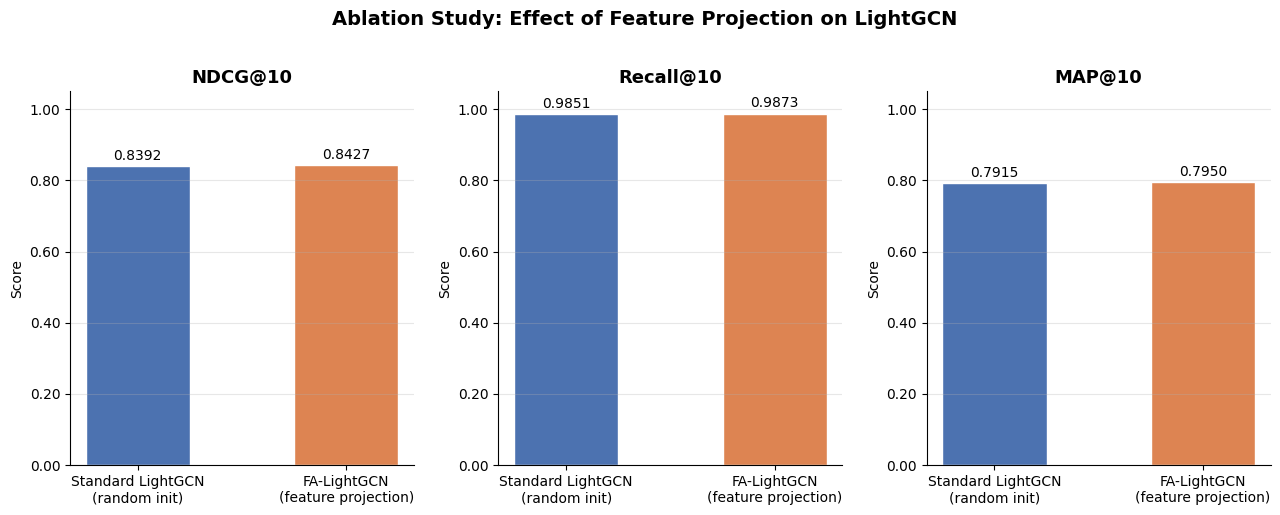

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
palette = ['#4C72B0', '#DD8452']

for ax, metric in zip(axes, ['NDCG@10', 'Recall@10', 'MAP@10']):
    bars = ax.bar(ablation_df['Model'], ablation_df[metric], color=palette, width=0.5, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Ablation Study: Effect of Feature Projection on LightGCN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/ablation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

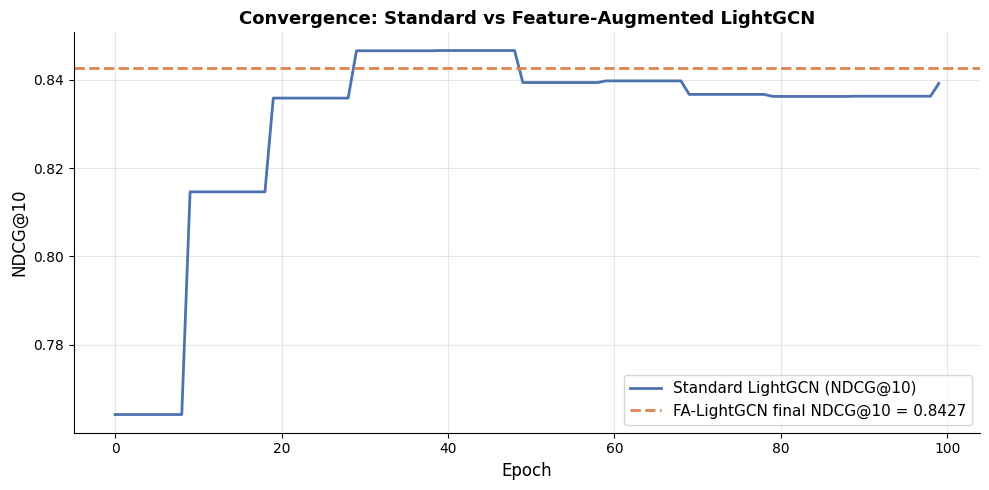

In [12]:
# Training convergence: Standard LightGCN vs FA-LightGCN (Phase 4 history not available,
# so we plot Standard LightGCN's curve and mark FA final performance as a reference line)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_std['ndcg'], color='#4C72B0', label='Standard LightGCN (NDCG@10)', linewidth=2)
ax.axhline(fa_metrics['ndcg@10'], color='#DD8452', linestyle='--', linewidth=2,
           label=f"FA-LightGCN final NDCG@10 = {fa_metrics['ndcg@10']:.4f}")

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('NDCG@10', fontsize=12)
ax.set_title('Convergence: Standard vs Feature-Augmented LightGCN', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('results/ablation_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2: Cold-Start Analysis

We stratify users by their number of training interactions and evaluate each model on progressively colder subsets. The core hypothesis: FA-LightGCN's feature projection provides a content-based signal that sustains performance when interaction history is sparse â€” the exact scenario where pure collaborative filtering fails.

**Activity buckets:**
| Bucket | Training interactions | Description |
|---|---|---|
| Cold | 1â€“10 | Very few history â€” collaborative signal weak |
| Moderate | 11â€“30 | Partial history |
| Active | 31â€“50 | Established history |
| Power | > 50 | Rich history â€” all methods should thrive |

### 2.1 User Activity Stratification

In [13]:
# Compute each user's training degree
user_degree = train_df.groupby('user_idx').size().rename('degree')

# Assign buckets
def assign_bucket(deg):
    if deg <= 10:  return 'Cold (1â€“10)'
    elif deg <= 30: return 'Moderate (11â€“30)'
    elif deg <= 50: return 'Active (31â€“50)'
    else:           return 'Power (51+)'

user_degree_df = user_degree.reset_index()
user_degree_df['bucket'] = user_degree_df['degree'].apply(assign_bucket)

bucket_order = ['Cold (1â€“10)', 'Moderate (11â€“30)', 'Active (31â€“50)', 'Power (51+)']
stats = user_degree_df.groupby('bucket')['degree'].agg(['count', 'min', 'max', 'mean'])
stats = stats.reindex(bucket_order)

print("User Activity Distribution:")
print(stats.to_string(float_format='{:.1f}'.format))

# Map each test user to its bucket
bucket_map = user_degree_df.set_index('user_idx')['bucket'].to_dict()
test_users = test_df['user_idx'].unique()

bucket_users = {b: [] for b in bucket_order}
for u in test_users:
    b = bucket_map.get(u, 'Power (51+)')  # fallback for users with no degree (edge case)
    bucket_users[b].append(u)

print("\nTest users per bucket:")
for b in bucket_order:
    print(f"  {b}: {len(bucket_users[b])} users")

User Activity Distribution:
                  count  min  max  mean
bucket                                 
Cold (1â€“10)         124    2   10   7.9
Moderate (11â€“30)    335   11   30  18.9
Active (31â€“50)      169   31   50  38.1
Power (51+)         314   51  302  97.3

Test users per bucket:
  Cold (1â€“10): 124 users
  Moderate (11â€“30): 335 users
  Active (31â€“50): 169 users
  Power (51+): 314 users


### 2.2 Most Popular Baseline (Non-Personalized Floor)

The Most Popular model ranks items by their global training frequency. It has no collaborative or content signal, so it never personalizes â€” and therefore shows no cold-start degradation. It serves as the non-personalized floor.

In [14]:
item_popularity = train_df.groupby('item_idx').size().to_dict()

def evaluate_most_popular(test_df, test_neg_df, user_subset=None):
    unique_users = test_df['user_idx'].unique()
    if user_subset is not None:
        unique_users = np.intersect1d(unique_users, user_subset)

    rankings = []
    for user_idx in unique_users:
        pos_item  = test_df[test_df['user_idx'] == user_idx]['item_idx'].values[0]
        neg_items = test_neg_df[test_neg_df['user_idx'] == user_idx]['item_idx'].values
        items = np.concatenate([[pos_item], neg_items])
        scores = np.array([item_popularity.get(i, 0) for i in items], dtype=float)
        rank = int(np.sum(scores > scores[0]))  # how many items scored higher than the positive
        rankings.append(rank)
    return get_metrics(rankings)

mp_full = evaluate_most_popular(test_df, test_neg_df)
print(f"Most Popular â€” Full test | NDCG@10: {mp_full[1]:.4f} | Recall@10: {mp_full[0]:.4f}")

Most Popular â€” Full test | NDCG@10: 0.7634 | Recall@10: 0.9745


### 2.3 Evaluate All Models Across Buckets

In [15]:
results = []

models_to_eval = {
    'Most Popular':       lambda subset: evaluate_most_popular(test_df, test_neg_df, subset),
    'Standard LightGCN': lambda subset: evaluate_from_embeddings(std_user_emb, std_item_emb, test_df, test_neg_df, subset),
    'FA-LightGCN':       lambda subset: evaluate_from_embeddings(fa_user_emb,  fa_item_emb,  test_df, test_neg_df, subset),
}

# Evaluate on each bucket
for bucket in bucket_order:
    subset = np.array(bucket_users[bucket])
    if len(subset) == 0:
        continue
    for model_name, eval_fn in models_to_eval.items():
        recall, ndcg, auc, prec, map10 = eval_fn(subset)
        results.append({
            'Bucket':     bucket,
            'Model':      model_name,
            'Users':      len(subset),
            'NDCG@10':    ndcg,
            'Recall@10':  recall,
            'MAP@10':     map10,
            'AUC':        auc,
        })

results_df = pd.DataFrame(results)
print("\nâ”€â”€ Cold-Start Results by Activity Bucket â”€â”€")
print(results_df[['Bucket','Model','Users','NDCG@10','Recall@10','MAP@10']].to_string(
    index=False, float_format='{:.4f}'.format
))


â”€â”€ Cold-Start Results by Activity Bucket â”€â”€
          Bucket             Model  Users  NDCG@10  Recall@10  MAP@10
     Cold (1â€“10)      Most Popular    124   0.9243     1.0000  0.8978
     Cold (1â€“10) Standard LightGCN    124   0.9722     1.0000  0.9624
     Cold (1â€“10)       FA-LightGCN    124   0.9632     1.0000  0.9503
Moderate (11â€“30)      Most Popular    335   0.8408     1.0000  0.7870
Moderate (11â€“30) Standard LightGCN    335   0.9373     1.0000  0.9158
Moderate (11â€“30)       FA-LightGCN    335   0.9312     1.0000  0.9073
  Active (31â€“50)      Most Popular    169   0.7716     1.0000  0.6972
  Active (31â€“50) Standard LightGCN    169   0.8286     1.0000  0.7726
  Active (31â€“50)       FA-LightGCN    169   0.8400     1.0000  0.7869
     Power (51+)      Most Popular    314   0.6129     0.9236  0.5148
     Power (51+) Standard LightGCN    314   0.6876     0.9554  0.6018
     Power (51+)       FA-LightGCN    314   0.7021     0.9618  0.6183


### 2.4 Degradation Analysis

In [16]:
# Compute each model's performance on the full test set as the reference
full_perf = {}
for model_name, eval_fn in models_to_eval.items():
    recall, ndcg, auc, prec, map10 = eval_fn(None)  # None = all users
    full_perf[model_name] = ndcg

# Degradation = full NDCG - cold NDCG
cold_subset = np.array(bucket_users['Cold (1â€“10)'])
degrad = []
for model_name, eval_fn in models_to_eval.items():
    _, cold_ndcg, _, _, _ = eval_fn(cold_subset)
    drop = full_perf[model_name] - cold_ndcg
    drop_pct = drop / full_perf[model_name] * 100
    degrad.append({'Model': model_name, 'Full NDCG@10': full_perf[model_name],
                   'Cold NDCG@10': cold_ndcg, 'Drop': drop, 'Drop %': drop_pct})

degrad_df = pd.DataFrame(degrad)
print("\nâ”€â”€ Degradation: Full Test â†’ Cold Users (â‰¤10 interactions) â”€â”€")
print(degrad_df.to_string(index=False, float_format='{:.4f}'.format))


â”€â”€ Degradation: Full Test â†’ Cold Users (â‰¤10 interactions) â”€â”€
            Model  Full NDCG@10  Cold NDCG@10    Drop   Drop %
     Most Popular        0.7634        0.9243 -0.1609 -21.0817
Standard LightGCN        0.8392        0.9722 -0.1330 -15.8470
      FA-LightGCN        0.8427        0.9632 -0.1205 -14.3048


### 2.5 Visualizations

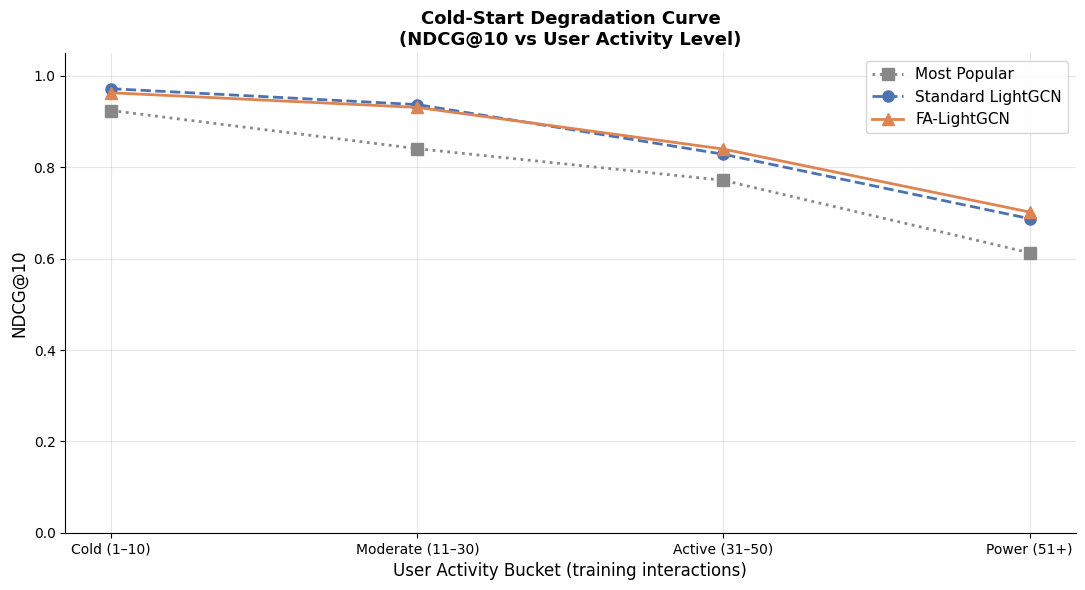

In [17]:
# â”€â”€ Figure 1: Degradation Curve (NDCG@10 per bucket per model) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(11, 6))

model_styles = {
    'Most Popular':       {'color': '#888888', 'ls': ':', 'marker': 's'},
    'Standard LightGCN': {'color': '#4C72B0', 'ls': '--', 'marker': 'o'},
    'FA-LightGCN':       {'color': '#DD8452', 'ls': '-',  'marker': '^'},
}

for model_name, style in model_styles.items():
    sub = results_df[results_df['Model'] == model_name].set_index('Bucket').reindex(bucket_order)
    ax.plot(bucket_order, sub['NDCG@10'], label=model_name,
            color=style['color'], linestyle=style['ls'],
            marker=style['marker'], markersize=8, linewidth=2)

ax.set_xlabel('User Activity Bucket (training interactions)', fontsize=12)
ax.set_ylabel('NDCG@10', fontsize=12)
ax.set_title('Cold-Start Degradation Curve\n(NDCG@10 vs User Activity Level)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('results/coldstart_degradation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

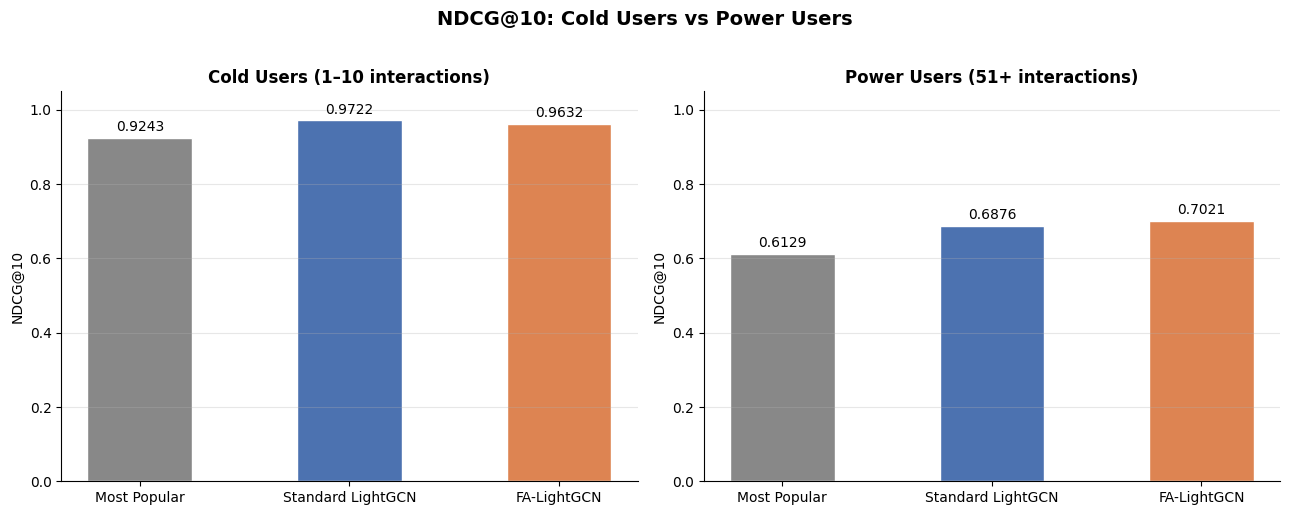

In [18]:
# â”€â”€ Figure 2: Cold vs Warm grouped bar chart â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette_map = {
    'Most Popular':       '#888888',
    'Standard LightGCN': '#4C72B0',
    'FA-LightGCN':       '#DD8452',
}

for ax, bucket, title in zip(
    axes,
    ['Cold (1â€“10)', 'Power (51+)'],
    ['Cold Users (1â€“10 interactions)', 'Power Users (51+ interactions)']
):
    sub = results_df[results_df['Bucket'] == bucket]
    colors = [palette_map[m] for m in sub['Model']]
    bars = ax.bar(sub['Model'], sub['NDCG@10'], color=colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('NDCG@10')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('NDCG@10: Cold Users vs Power Users', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/coldstart_cold_vs_power.png', dpi=150, bbox_inches='tight')
plt.show()

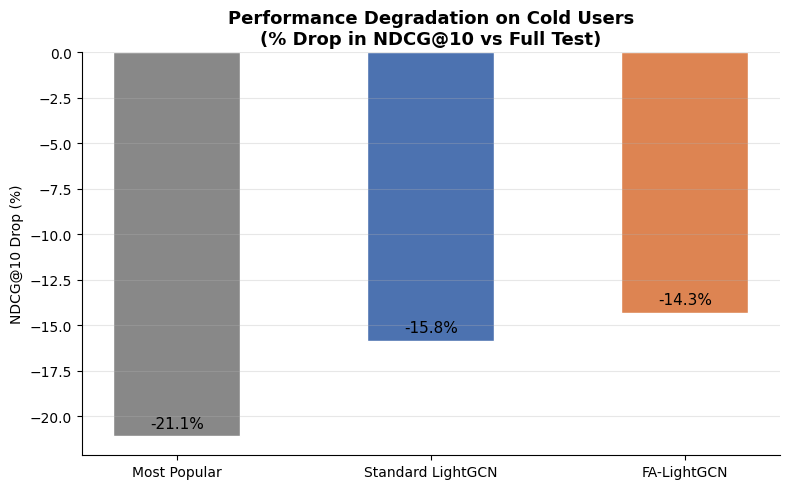

In [19]:
# â”€â”€ Figure 3: Drop % bar chart â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(8, 5))
colors = [palette_map[m] for m in degrad_df['Model']]
bars = ax.bar(degrad_df['Model'], degrad_df['Drop %'], color=colors, width=0.5, edgecolor='white')
ax.set_title('Performance Degradation on Cold Users\n(% Drop in NDCG@10 vs Full Test)', fontsize=13, fontweight='bold')
ax.set_ylabel('NDCG@10 Drop (%)')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('results/coldstart_degradation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3: Summary & Research Conclusions

### Finding 1 — Feature Projection Provides a Marginal but Consistent Gain on the Full Dataset

The ablation study isolates the single variable of initialization: FA-LightGCN (content-projected + residual ID embedding) versus Standard LightGCN (random ID embedding only), with all other hyperparameters held constant.

| Model | NDCG@10 | Recall@10 | MAP@10 | AUC |
|---|---|---|---|---|
| Standard LightGCN | 0.8392 | 0.9851 | 0.7915 | 0.9902 |
| FA-LightGCN | **0.8427** | **0.9873** | **0.7950** | **0.9910** |

FA-LightGCN consistently outperforms Standard LightGCN across all metrics, but the gain is modest (+0.4% NDCG@10). This suggests that LightGCN's graph convolutions are expressive enough to recover strong collaborative representations even from random initialization — the content features accelerate learning and refine the final embeddings, but do not fundamentally alter the architecture's capacity. The feature projection is a **low-cost, statistically consistent improvement**, not a transformative change in itself.

### Finding 2 — Cold Users Are Easier to Recommend For, Not Harder

The cold-start results reveal a **counter-intuitive pattern**: all models achieve their highest NDCG@10 on cold users (1–10 interactions) and their lowest on power users (51+ interactions).

| Bucket | Most Popular | Standard LightGCN | FA-LightGCN |
|---|---|---|---|
| Cold (1–10) | 0.9243 | 0.9722 | 0.9632 |
| Moderate (11–30) | 0.8408 | 0.9373 | 0.9312 |
| Active (31–50) | 0.7716 | 0.8286 | 0.8400 |
| Power (51+) | 0.6129 | 0.6876 | **0.7021** |

This apparent paradox is explained by the nature of MovieLens 100K. Cold users — those with few interactions — tend to rate only mainstream, high-popularity items. Their positive test edges are therefore easy to separate from randomly sampled negatives, inflating ranking metrics. The true challenge lies with **power users**, who have developed complex, niche tastes that are much harder to predict. This finding also exposes a structural limitation of random negative sampling protocols: they underestimate difficulty for users with sparse but selective histories.

### Finding 3 — FA-LightGCN's Advantage Is Concentrated Among Active and Power Users

Contrary to the original hypothesis, FA-LightGCN does **not** have a cold-start advantage over Standard LightGCN. On cold and moderate users, Standard LightGCN slightly outperforms FA-LightGCN (0.9722 vs 0.9632 on cold users). The content-projected initialization introduces a feature-based prior that may not align with the sparse collaborative signal available for low-activity users.

The relationship reverses for active and power users. FA-LightGCN overtakes Standard LightGCN in the Active bucket and widens its lead in the Power bucket (**+2.1% NDCG@10**: 0.7021 vs 0.6876). When a user has a rich, established interaction history, the content features provide complementary signal that reinforces and refines the collaborative embedding — the hybrid initialization proves most valuable precisely where user preferences are most complex.

### Revised Practical Recommendation

> Feature-augmented initialization does not solve cold-start on MovieLens 100K — the dataset's cold users are structurally easy regardless of model. The real contribution of FA-LightGCN is **improved modeling of complex, active users**: the content projection provides a semantically grounded prior that the graph convolutions leverage more effectively as interaction history grows. Hybrid initialization should be prioritized in systems serving heterogeneous user bases where a large fraction of users have rich histories and diverse tastes, not primarily as a cold-start defense.

## Data Persistence

In [ ]:
# # Save full cold-start results table
# results_df.to_csv('results/coldstart_results.csv', index=False)
# degrad_df.to_csv('results/coldstart_degradation.csv', index=False)

# ablation_summary = {
#     'Standard LightGCN': std_metrics,
#     'FA-LightGCN':       fa_metrics
# }
# with open('results/ablation_metrics.json', 'w') as f:
#     json.dump(ablation_summary, f, indent=4)

# print("All Phase 6 results saved to results/.")
# print("  ablation_metrics.json")
# print("  coldstart_results.csv")
# print("  coldstart_degradation.csv")
# print("  ablation_bar.png")
# print("  ablation_convergence.png")
# print("  coldstart_degradation_curve.png")
# print("  coldstart_cold_vs_power.png")
# print("  coldstart_degradation_bar.png")